# SentinelGuard File 4 - SHAP Explainability

File 3 gave me the tuned model with Isolation Forest. This notebook adds explainability using SHAP. The idea is that when the model flags a transaction as fraud, it needs to explain why - which features caused the flag and by how much. This is required under GDPR Article 22 for automated banking decisions.

Two outputs from this notebook:
1. Global SHAP plot - which features matter most overall
2. Local waterfall plot - why one specific fraud transaction was flagged

## setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install shap xgboost --quiet

loading the final model and test set saved in week 3

In [4]:
import shap
import xgboost as xgb

# load final model (tuned xgboost with isolation forest feature)
with open('/content/drive/MyDrive/Project/xgb_final.pkl', 'rb') as f:
    model = pickle.load(f)

# load test set with iso_score already added
X_test = pd.read_csv('/content/drive/MyDrive/Project/X_test_iso.csv')
y_test = pd.read_csv('/content/drive/MyDrive/Project/y_test.csv').squeeze()

print('model loaded')
print('test set shape:', X_test.shape)
print('fraud in test:', y_test.sum())

model loaded
test set shape: (554082, 7)
fraud in test: 1643


## Global SHAP - which features matter most overall

SHAP values tell you how much each feature contributed to the prediction. The global plot averages this across all test transactions to show which features the model relies on most.

In [5]:
# create explainer
explainer = shap.TreeExplainer(model)

# computing shap values on a sample of 2000 to keep it fast
# full test set would take too long
sample_idx = X_test.sample(2000, random_state=42).index
X_sample = X_test.loc[sample_idx]

print('computing SHAP values on 2000 sample transactions...')
shap_values = explainer.shap_values(X_sample)

computing SHAP values on 2000 sample transactions...


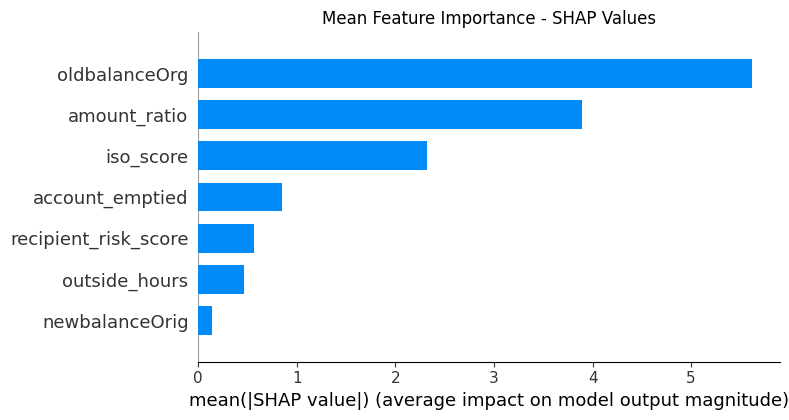

saved shap_global_importance.png


In [6]:
# global bar chart - mean absolute SHAP value per feature
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Mean Feature Importance - SHAP Values')
plt.tight_layout()
plt.savefig('shap_global_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved shap_global_importance.png')

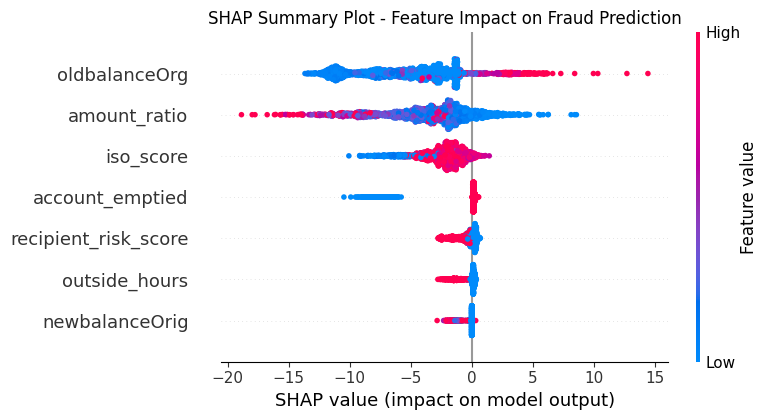

saved shap_summary_beeswarm.png


In [7]:
# beeswarm plot - shows both importance and direction of each feature
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Fraud Prediction')
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved shap_summary_beeswarm.png')

## Local explanation - why was this specific transaction flagged

Picking one fraud transaction from the test set and explaining exactly why the model flagged it. This is what a bank compliance team would see when a customer asks why their transaction was blocked.

In [8]:
# find fraud transactions in the test set
fraud_indices = y_test[y_test == 1].index

# pick the first fraud transaction for explanation
example_idx = fraud_indices[0]
example = X_test.loc[[example_idx]]

print('example fraud transaction:')
print(example.T)
print()
print('model prediction:', model.predict(example)[0], '(1 = fraud)')
print('fraud probability:', round(model.predict_proba(example)[0][1], 4))

example fraud transaction:
                                96
amount_ratio          1.538462e+05
outside_hours         1.000000e+00
account_emptied       0.000000e+00
recipient_risk_score  0.000000e+00
oldbalanceOrg         2.549486e+07
newbalanceOrig        1.549486e+07
iso_score             2.865140e-03

model prediction: 1 (1 = fraud)
fraud probability: 0.9999


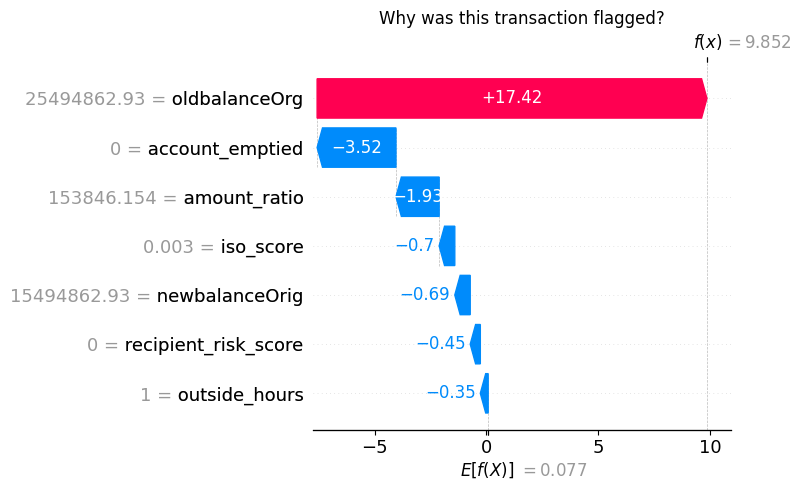

saved shap_waterfall_fraud_example.png


In [9]:
# waterfall plot for this one transaction
# shows which features pushed the prediction toward fraud and by how much
shap_example = explainer.shap_values(example)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_example[0],
        base_values=explainer.expected_value,
        data=example.iloc[0],
        feature_names=list(X_test.columns)
    ),
    show=False
)
plt.title('Why was this transaction flagged?')
plt.tight_layout()
plt.savefig('shap_waterfall_fraud_example.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved shap_waterfall_fraud_example.png')

## Local explanation for a normal transaction

Also showing what a normal transaction looks like to the model - features should push it toward 0 (not fraud).

In [10]:
# pick one normal transaction
normal_indices = y_test[y_test == 0].index
normal_idx = normal_indices[0]
normal_example = X_test.loc[[normal_idx]]

print('example normal transaction:')
print(normal_example.T)
print()
print('model prediction:', model.predict(normal_example)[0], '(0 = normal)')
print('fraud probability:', round(model.predict_proba(normal_example)[0][1], 4))

example normal transaction:
                                0
amount_ratio          1690.248923
outside_hours            0.000000
account_emptied          1.000000
recipient_risk_score     0.000000
oldbalanceOrg         7071.000000
newbalanceOrig           0.000000
iso_score                0.450556

model prediction: 0 (0 = normal)
fraud probability: 0.0


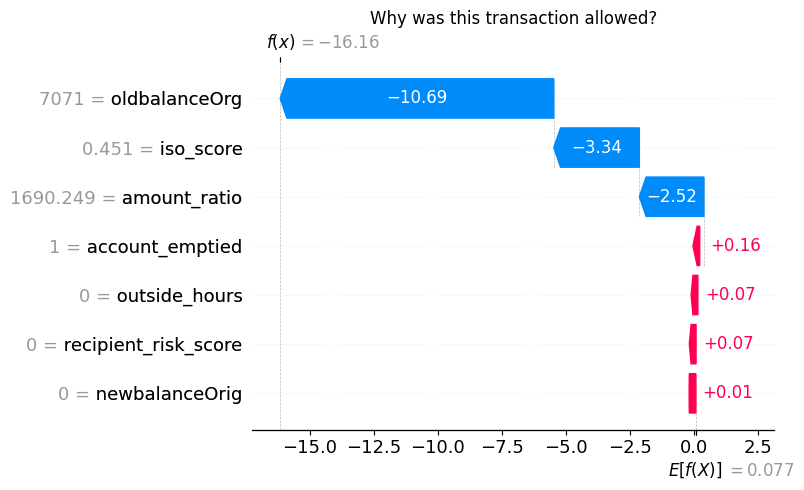

saved shap_waterfall_normal_example.png


In [11]:
shap_normal = explainer.shap_values(normal_example)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_normal[0],
        base_values=explainer.expected_value,
        data=normal_example.iloc[0],
        feature_names=list(X_test.columns)
    ),
    show=False
)
plt.title('Why was this transaction allowed?')
plt.tight_layout()
plt.savefig('shap_waterfall_normal_example.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved shap_waterfall_normal_example.png')

## Results summary across all 4 weeks

Putting together a clean results table for the Milestone 2 presentation.

In [12]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('final model results')
print()
print(f'precision (fraud):   {round(report["1"]["precision"], 4)}')
print(f'recall (fraud):      {round(report["1"]["recall"], 4)}')
print(f'f1 (fraud):          {round(report["1"]["f1-score"], 4)}')
print(f'AUC:                 {round(roc_auc_score(y_test, y_prob), 4)}')
print()
print(f'fraud caught (TP):   {tp}')
print(f'fraud missed (FN):   {fn}')
print(f'false alarms (FP):   {fp}')
print(f'false positive rate: {round(fp/(fp+tn)*100, 4)}%')
print()
print('comparison across milestones')
print(f'{"metric":<20} {"baseline":<12} {"tuned":<12} {"tuned+IF"}')
print(f'{"precision":<20} {"0.4603":<12} {"0.4932":<12} {round(report["1"]["precision"], 4)}')
print(f'{"recall":<20} {"0.9951":<12} {"0.9933":<12} {round(report["1"]["recall"], 4)}')
print(f'{"AUC":<20} {"0.9983":<12} {"0.9984":<12} {round(roc_auc_score(y_test, y_prob), 4)}')

final model results

precision (fraud):   0.4898
recall (fraud):      0.9909
f1 (fraud):          0.6555
AUC:                 0.9985

fraud caught (TP):   1628
fraud missed (FN):   15
false alarms (FP):   1696
false positive rate: 0.307%

comparison across milestones
metric               baseline     tuned        tuned+IF
precision            0.4603       0.4932       0.4898
recall               0.9951       0.9933       0.9909
AUC                  0.9983       0.9984       0.9985


## notes

SHAP is working and the plots are saved.

The global plot shows which features the model relies on most. The waterfall plots show exactly why individual transactions were flagged or allowed - this is what satisfies GDPR Article 22 for automated banking decisions.

